In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds


In [ ]:
datos, metadatos = tfds.load('fashion_mnist', as_supervised=True, with_info=True)


In [ ]:
metadatos

tfds.core.DatasetInfo(
    name='fashion_mnist',
    full_name='fashion_mnist/3.0.1',
    description="""
    Fashion-MNIST is a dataset of Zalando's article images consisting of a training set of 60,000 examples and a test set of 10,000 examples. Each example is a 28x28 grayscale image, associated with a label from 10 classes.
    """,
    homepage='https://github.com/zalandoresearch/fashion-mnist',
    data_dir='/root/tensorflow_datasets/fashion_mnist/3.0.1',
    file_format=tfrecord,
    download_size=29.45 MiB,
    dataset_size=36.42 MiB,
    features=FeaturesDict({
        'image': Image(shape=(28, 28, 1), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test': <SplitInfo num_examples=10000, num_shards=1>,
        'train': <SplitInfo num_examples=60000, num_shards=1>,
    },
    citation="""@article{DBLP:journals/corr

In [ ]:
datos_entrenamiento, datos_pruebas = datos['train'], datos['test']

In [ ]:
nombres_clases = metadatos.features['label'].names
print("Nombres de las clases: ", nombres_clases)

Nombres de las clases:  ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [ ]:
def normalizar(imagenes, etiquetas):
    imagenes = tf.cast(imagenes, tf.float32)
    imagenes /= 255
    etiquetas = tf.cast(etiquetas, tf.int64) # Ensure labels are int64
    etiquetas = tf.reshape(etiquetas, []) # Ensure labels are scalar
    return imagenes, etiquetas

datos_entrenamiento = datos_entrenamiento.map(normalizar)
datos_pruebas = datos_pruebas.map(normalizar)

datos_entrenamiento = datos_entrenamiento.cache()
datos_pruebas = datos_pruebas.cache()

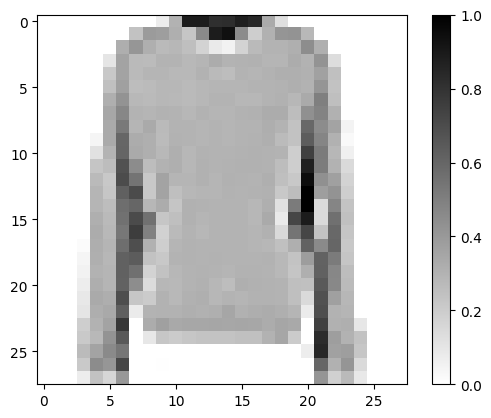

In [ ]:
for imagen, etiqueta in datos_entrenamiento.take(1):
    break


import matplotlib.pyplot as plt
plt.figure()
plt.imshow(imagen, cmap=plt.cm.binary)
plt.colorbar()
plt.show()

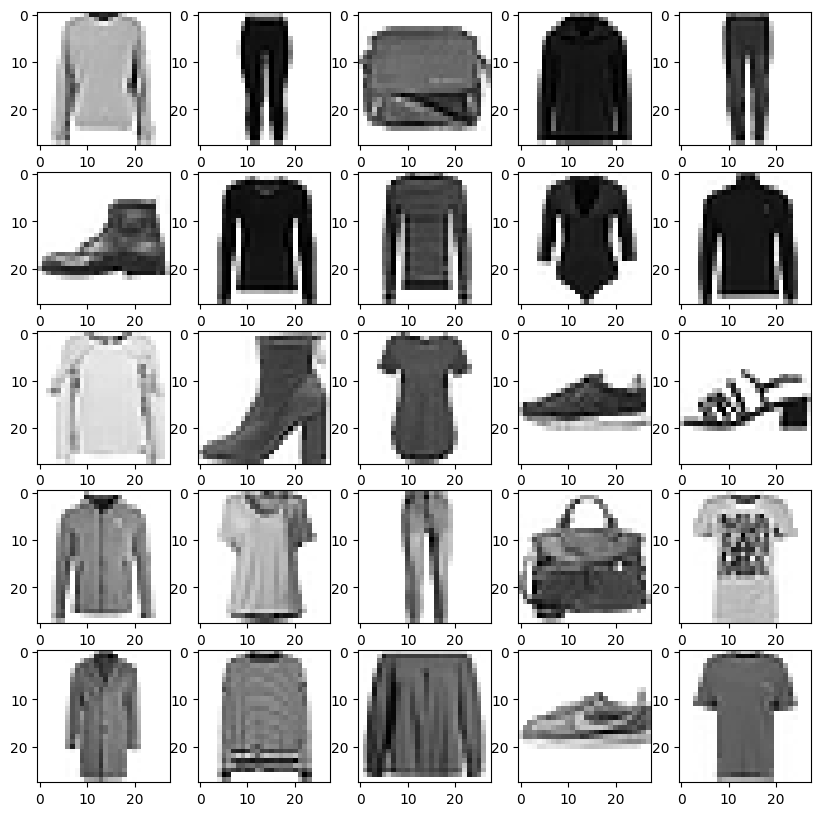

In [ ]:
plt.figure(figsize=(10,10))
for i, (imagen, etiqueta) in enumerate(datos_entrenamiento.take(25)):
  plt.subplot(5,5,i+1)
  plt.imshow(imagen, cmap=plt.cm.binary)

plt.show()

In [ ]:
modelo = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28,1)),
    tf.keras.layers.Dense(50, activation=tf.nn.relu),
    tf.keras.layers.Dense(50, activation=tf.nn.relu),
    tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
modelo.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [ ]:
TAMAND_LOTE = 32

datos_entrenamiento = datos_entrenamiento.repeat().shuffle(60000).batch(TAMAND_LOTE)
datos_pruebas = datos_pruebas.batch(TAMAND_LOTE)

In [ ]:
import math

entrenamiento = modelo.fit(datos_entrenamiento, epochs=10, steps_per_epoch=math.ceil(60000/TAMAND_LOTE))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.8170 - loss: 0.5171
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8623 - loss: 0.3797
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8739 - loss: 0.3462
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8817 - loss: 0.3222
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8867 - loss: 0.3023
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8917 - loss: 0.2932
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8944 - loss: 0.2833
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8992 - loss: 0.2718
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9018 - loss: 0.2625
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9031 - loss: 0.2583


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


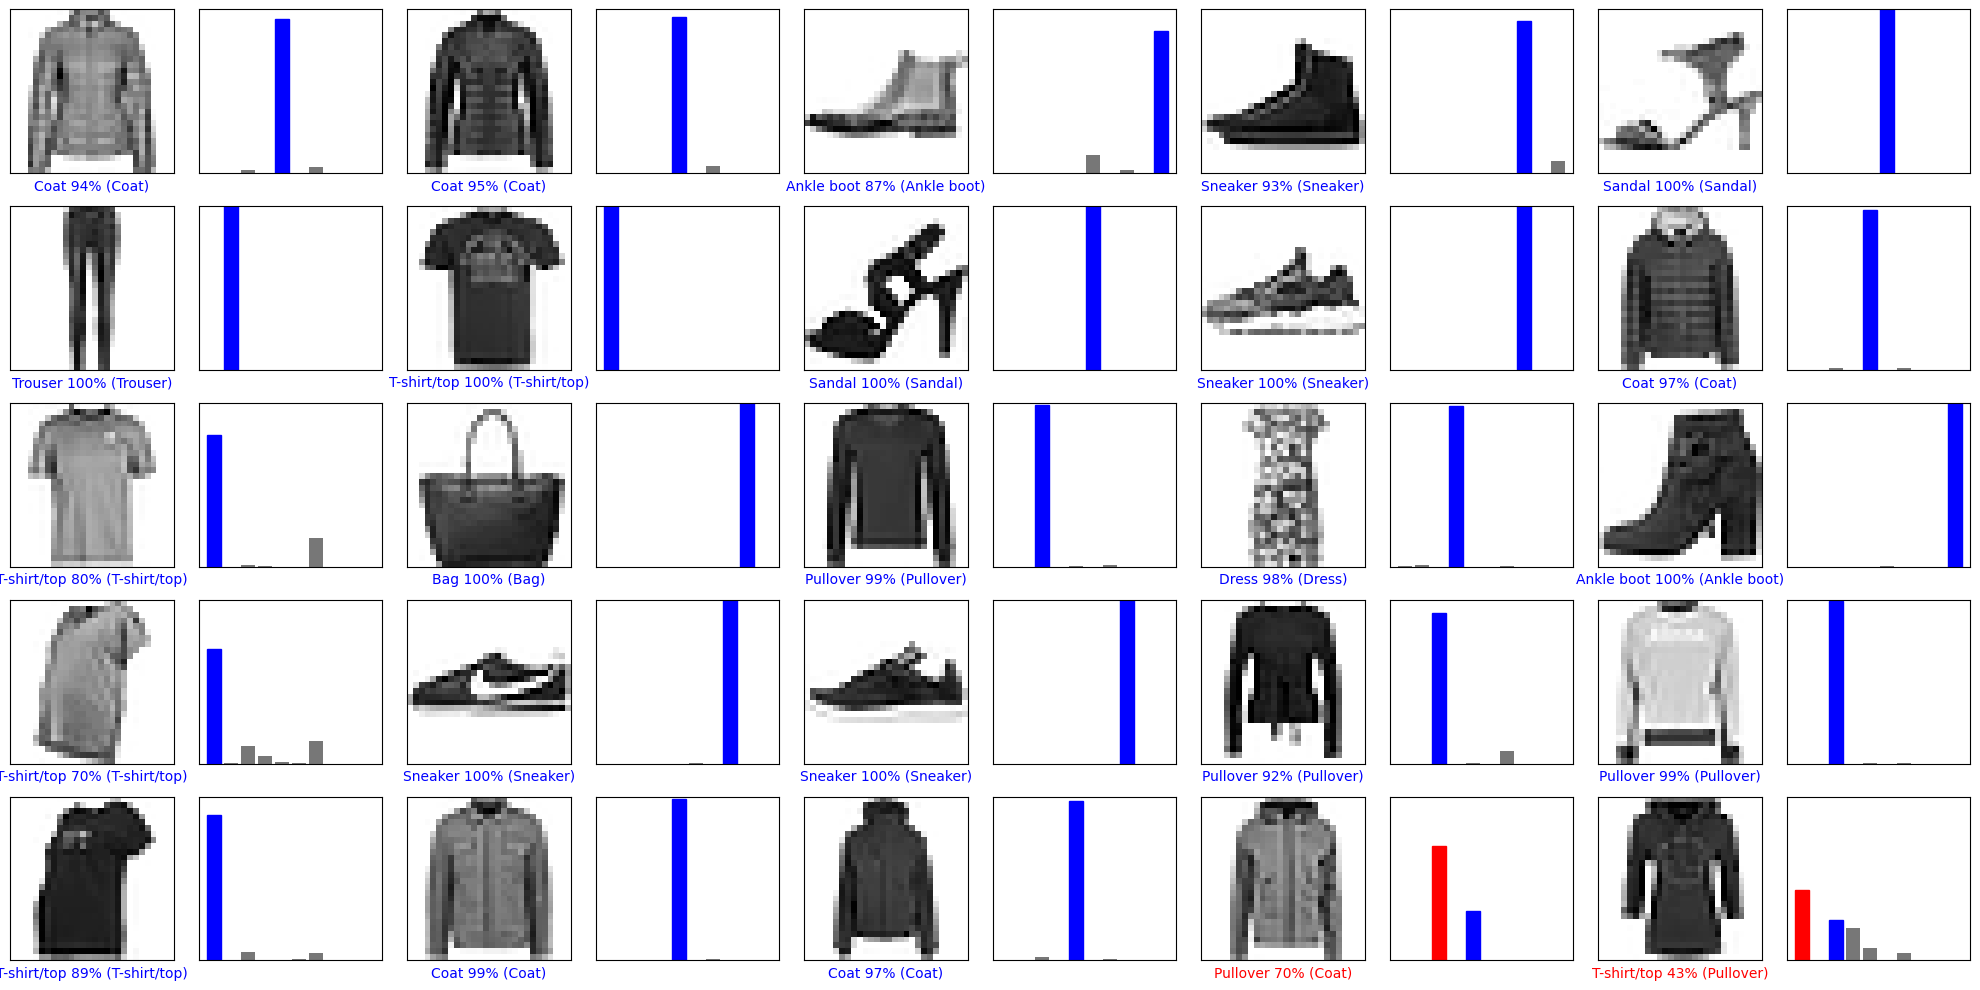

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Mostrar predicciones con aciertos (azul) y errores (rojo)
for imagenes_prueba, etiquetas_prueba in datos_pruebas.take(1):
    imagenes_prueba = imagenes_prueba.numpy()
    etiquetas_prueba = etiquetas_prueba.numpy()
    predicciones = modelo.predict(imagenes_prueba)

    def graficar_imagen(i, arr_predicciones, etiquetas_reales, imagenes):
        arr_prediccion = arr_predicciones[i]
        etiqueta_real = etiquetas_reales[i]
        img = imagenes[i]

        plt.grid(False)
        plt.xticks([])
        plt.yticks([])
        plt.imshow(img[..., 0], cmap=plt.cm.binary)

        etiqueta_prediccion = np.argmax(arr_prediccion)
        color = 'blue' if etiqueta_prediccion == etiqueta_real else 'red'

        plt.xlabel(f"{nombres_clases[etiqueta_prediccion]} {100*np.max(arr_prediccion):2.0f}% ({nombres_clases[etiqueta_real]})", color=color)

    def graficar_valor_arreglo(i, arr_predicciones, etiquetas_reales):
        arr_prediccion = arr_predicciones[i]
        etiqueta_real = etiquetas_reales[i]

        plt.grid(False)
        plt.xticks([])
        plt.yticks([])
        grafica = plt.bar(range(10), arr_prediccion, color="#777777")
        plt.ylim([0, 1])

        etiqueta_prediccion = np.argmax(arr_prediccion)
        grafica[etiqueta_prediccion].set_color('red')
        grafica[etiqueta_real].set_color('blue')

    # Configuración de la cuadrícula
    filas = 5
    columnas = 5
    num_imagenes = filas * columnas

    plt.figure(figsize=(2 * 2 * columnas, 2 * filas))

    for i in range(num_imagenes):
        # Imagen
        plt.subplot(filas, 2 * columnas, 2 * i + 1)
        graficar_imagen(i, predicciones, etiquetas_prueba, imagenes_prueba)

        # Gráfico de barras de predicciones
        plt.subplot(filas, 2 * columnas, 2 * i + 2)
        graficar_valor_arreglo(i, predicciones, etiquetas_prueba)

    plt.tight_layout()
    plt.show()